# Seoul Bikes EDA
### Evan André Santana Pacheco A01769493
### TC3009C.601

Predictive Modeling of Urban Bike-Sharing Demand in Seoul
Seoul Bike Sharing Demand (UCI Machine Learning Repository)
Authors
https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand

Licence
Creative Commons Attribution 4.0 International (CC BY 4.0)

References

Hue function
https://www.geeksforgeeks.org/python/seaborn-lineplot-method-in-python/

pd cut for discrete bins
https://pandas.pydata.org/docs/reference/api/pandas.cut.html

### Libraries

In [60]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

We load our clean data.

In [61]:
from google.colab import drive
drive.mount("/content/gdrive")
!pwd
%cd "/content/gdrive/MyDrive/IAconcentrada/seoul"
!ls

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
/content/gdrive/My Drive/IAconcentrada/seoul
/content/gdrive/MyDrive/IAconcentrada/seoul
 daily_temp_summary.csv   X_test_seoul.csv    Y_train_seoul.csv
'first version backup'	  X_train_seoul.csv   Y_val_seoul.csv
 map_seoulData.csv	  X_val_seoul.csv
 SeoulBikeData.csv	  Y_test_seoul.csv


Most of the data will be analized on the train subset.

In [62]:
Y_train = pd.read_csv('Y_train_seoul.csv', encoding='utf-8')
X_train = pd.read_csv('X_train_seoul.csv', encoding='utf-8')

print("Y_Train: \n",Y_train.head())
print("\n X_train: \n",X_train.head())

Y_Train: 
    Rented Bike Count
0                254
1                204
2                173
3                107
4                 78

 X_train: 
    Hour  Temperature(°C)  Humidity(%)  Wind speed (m/s)  Visibility (10m)  \
0     0             -5.2           37               2.2               1.0   
1     1             -5.5           38               0.8               1.0   
2     2             -6.0           39               1.0               1.0   
3     3             -6.2           40               0.9               1.0   
4     4             -6.0           36               2.3               1.0   

   Dew point temperature(°C)  Solar Radiation (MJ/m2)  Rainfall(mm)  \
0                      -17.6                      0.0           0.0   
1                      -17.6                      0.0           0.0   
2                      -17.7                      0.0           0.0   
3                      -17.6                      0.0           0.0   
4                      -18.6    

We can concatenate the Y and X train for studying it.

In [63]:
eda = pd.concat([Y_train, X_train], axis=1)

eda.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Weekend
0,254,0,-5.2,37,2.2,1.0,-17.6,0.0,0.0,0.0,1,0,0
1,204,1,-5.5,38,0.8,1.0,-17.6,0.0,0.0,0.0,1,0,0
2,173,2,-6.0,39,1.0,1.0,-17.7,0.0,0.0,0.0,1,0,0
3,107,3,-6.2,40,0.9,1.0,-17.6,0.0,0.0,0.0,1,0,0
4,78,4,-6.0,36,2.3,1.0,-18.6,0.0,0.0,0.0,1,0,0


## Histograms
Frequencies will provide a better understanding of the whole data in each feature.

For practical way we will define our variables into continous, discrete and categoric to simplify the graph creation.

For histograms we will focus only into proces only the continous variables including holiday.

Our discrete variable is Hour, no information needed to be inspected.
Our categorical variables are Weekend, Holiday and Season.
This variables can help us study more in detail, zoom in or zoom out the continous data durign the EDA.
The rest of the features are continous variables.

In [64]:
discrete = eda['Hour']
tempcate = ['Seasons','Holiday','Weekend']
categorical = eda[tempcate]

conti = list(eda.columns)
continous = eda[conti]
continous = continous.drop(tempcate, axis=1)
continous = continous.drop('Hour', axis=1)


print("Categorical data: \n", categorical.head())
print("Discrete data: \n",discrete.head())
print("Continous data: \n",continous.head())


Categorical data: 
    Seasons  Holiday  Weekend
0        1        0        0
1        1        0        0
2        1        0        0
3        1        0        0
4        1        0        0
Discrete data: 
 0    0
1    1
2    2
3    3
4    4
Name: Hour, dtype: int64
Continous data: 
    Rented Bike Count  Temperature(°C)  Humidity(%)  Wind speed (m/s)  \
0                254             -5.2           37               2.2   
1                204             -5.5           38               0.8   
2                173             -6.0           39               1.0   
3                107             -6.2           40               0.9   
4                 78             -6.0           36               2.3   

   Visibility (10m)  Dew point temperature(°C)  Solar Radiation (MJ/m2)  \
0               1.0                      -17.6                      0.0   
1               1.0                      -17.6                      0.0   
2               1.0                      -17.7       

We graph our continous variables including Holiday.

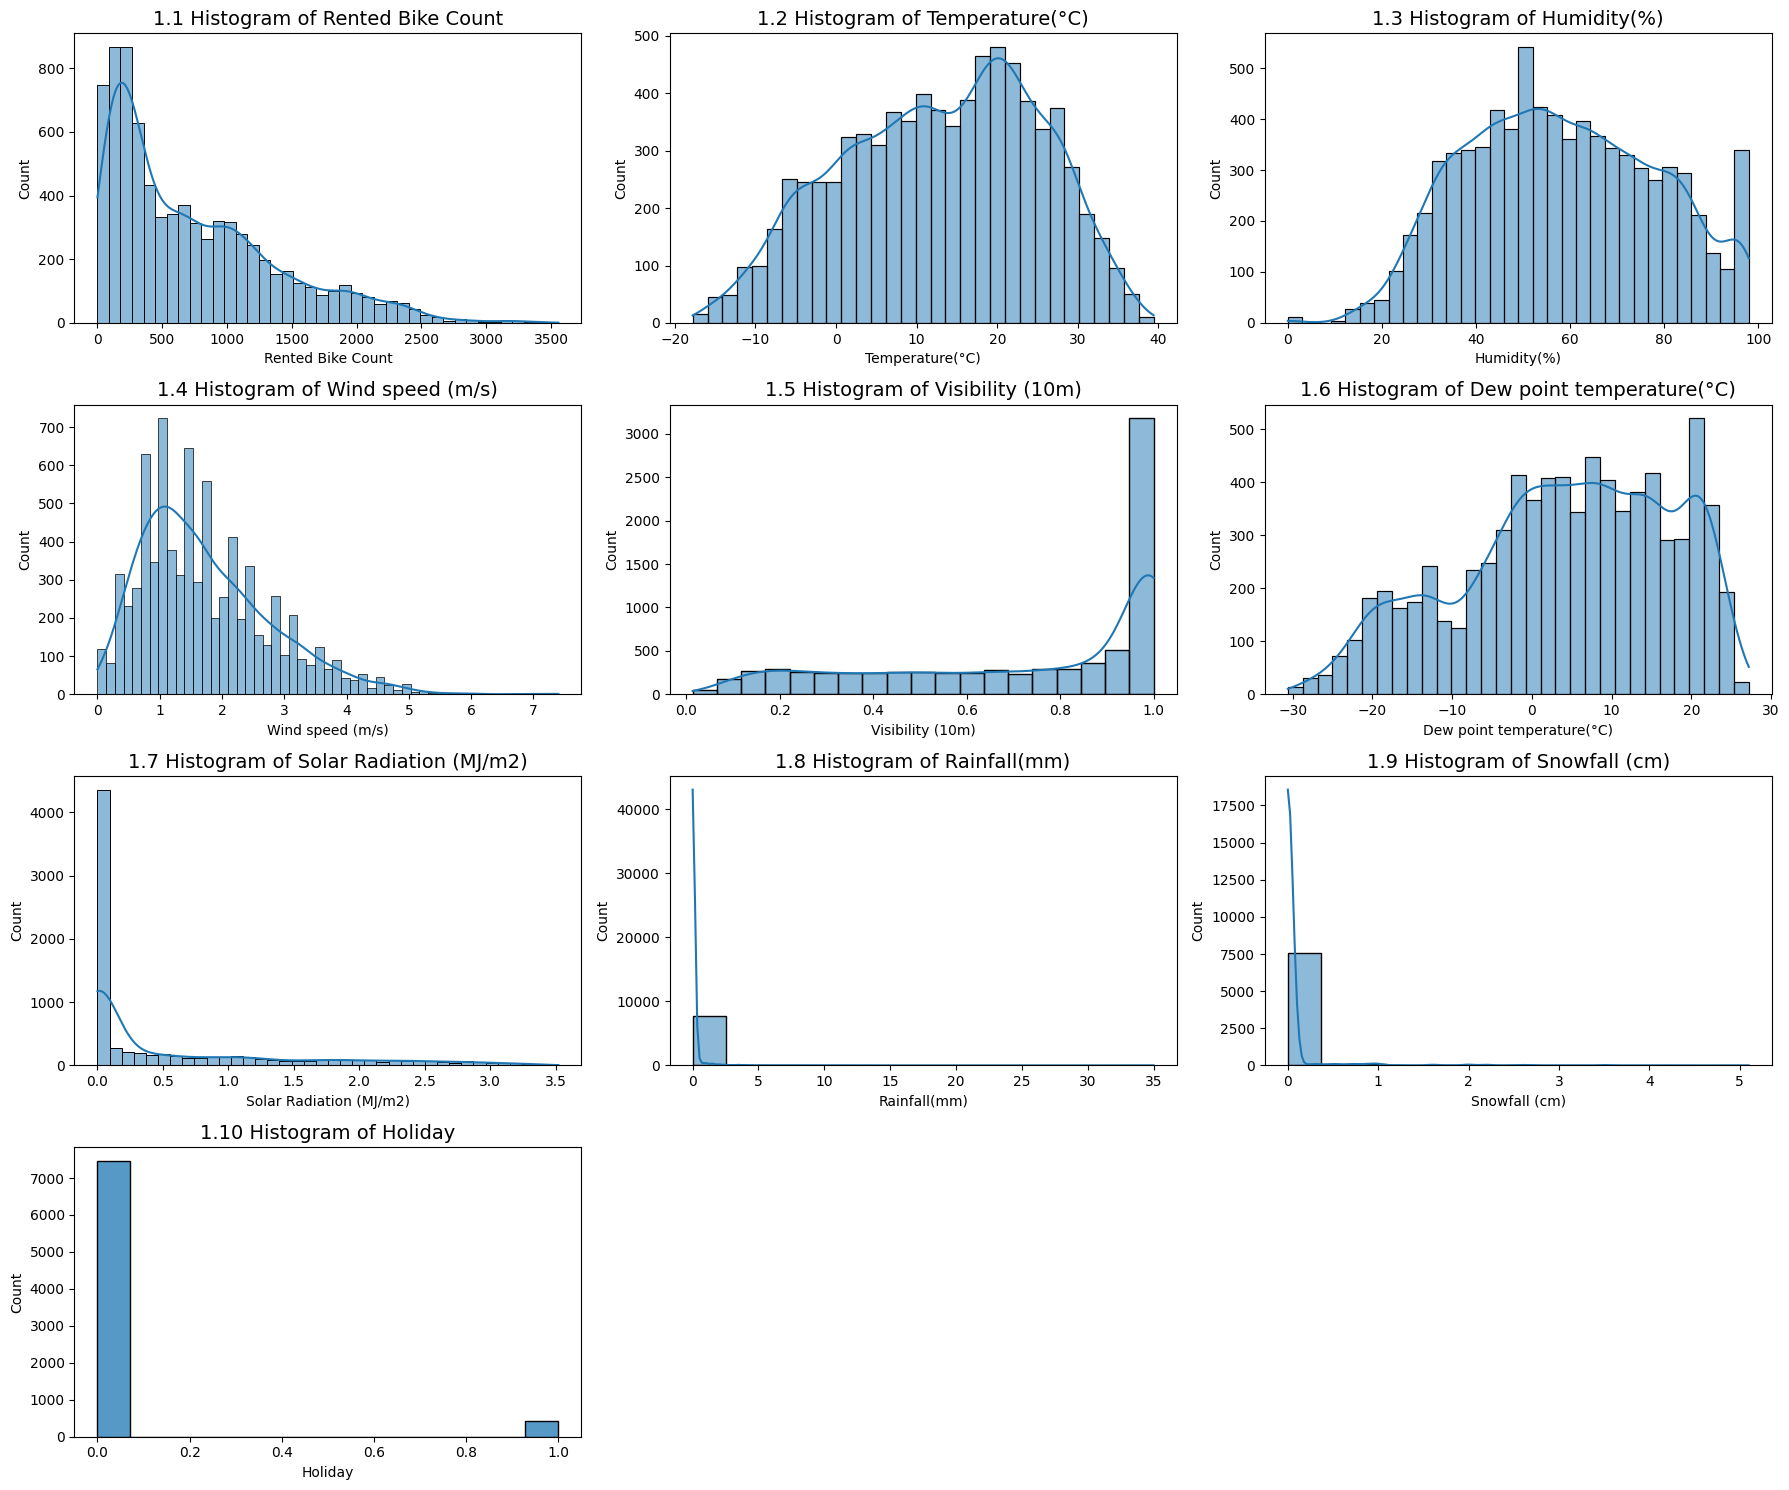

In [65]:
contcols = list(continous.columns)

fig, axes = plt.subplots(4, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(contcols):
    sns.histplot(continous[col], kde=True, ax=axes[i])
    axes[i].set_title(f'1.{i+1} Histogram of {col}', fontsize=14)

sns.histplot(categorical['Holiday'], ax=axes[9])
axes[9].set_title('1.10 Histogram of Holiday', fontsize=14)

for j in range(10, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
#To save the graph
#plt.savefig('fig_1_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

Snowfall and Rainfall cannot be well percieved we are gonna do a quick check on what is the maximum exact outlier that is not percived on the graph.

In [66]:
print(eda['Rainfall(mm)'].max())
print(eda['Snowfall (cm)'].max())

35.0
5.1


# Boxplots
This can tell us the outliers and distribution of the data better.

We obtain the box and whiskers graph for each continous variable.

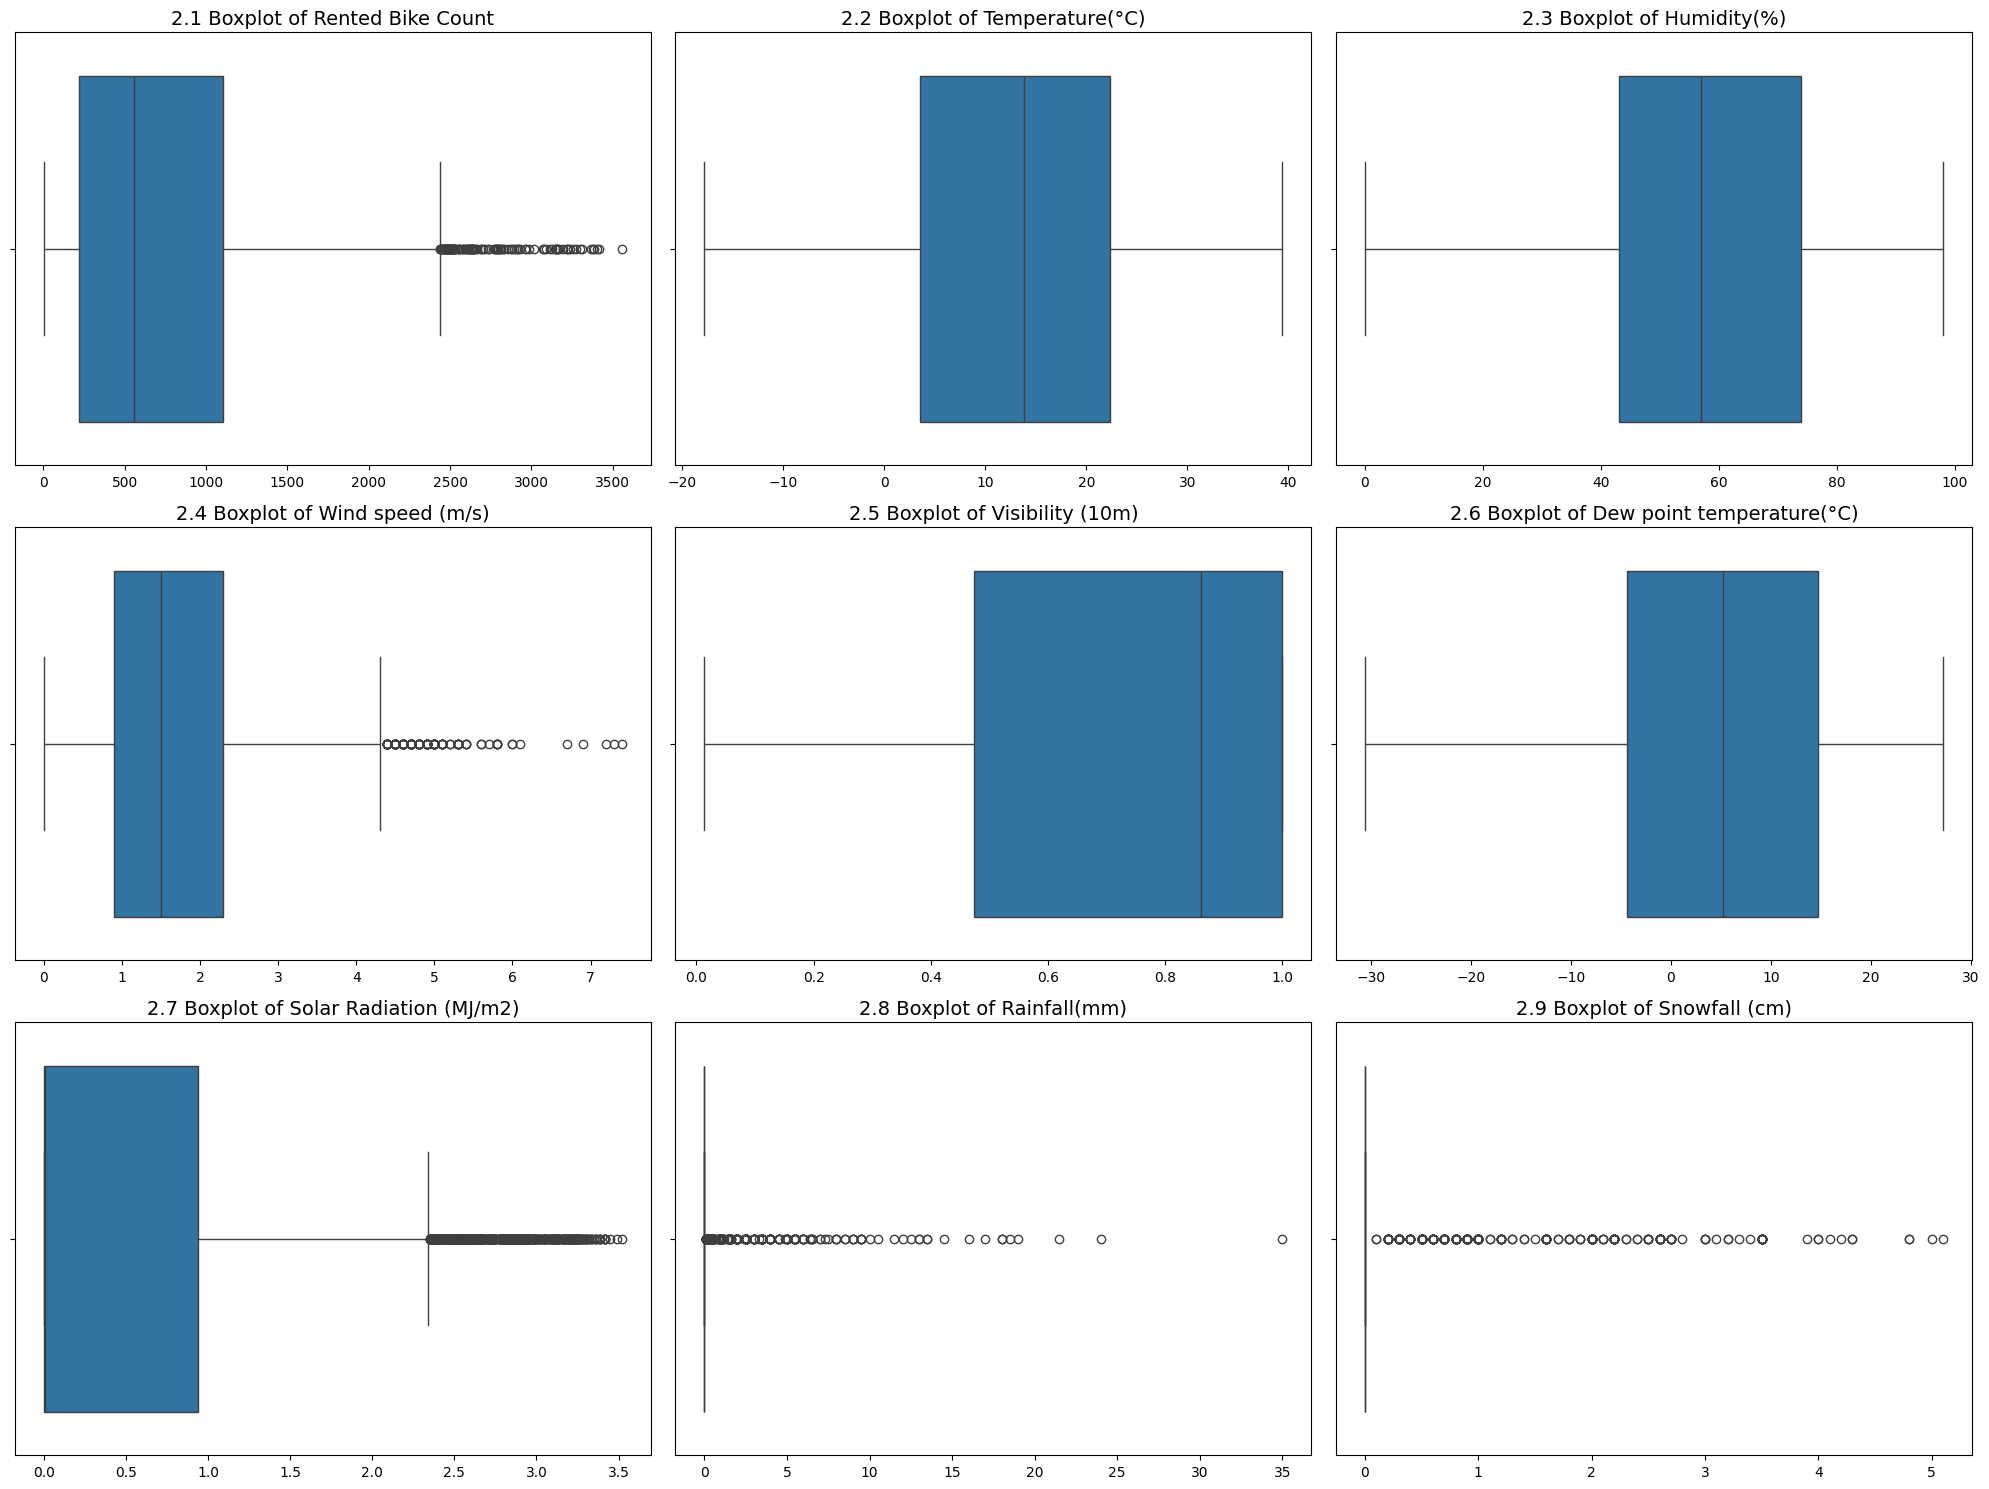

In [67]:
boxcols = continous.columns
n_cols = 3
n_rows = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(boxcols):
    sns.boxplot(x=eda[col], ax=axes[i])
    axes[i].set_title(f'2.{i+1} Boxplot of {col}', fontsize=14)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
#To save the graph
#plt.savefig('fig2_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

Command to save the graphs.

In [68]:
#plt.savefig('boxplot_edaSeoul.pdf', format='pdf', bbox_inches='tight')

We can benefit from our categorical data and produce a box and whiskers graph of our rented bikes divided on each category.

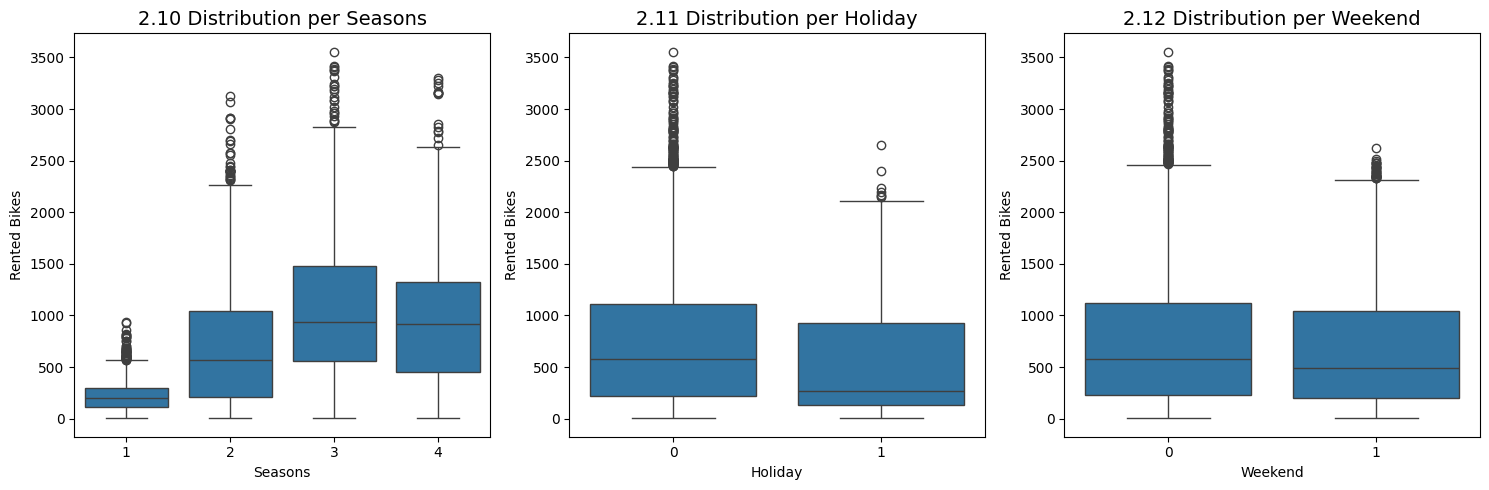

In [69]:
plt.figure(figsize=(15, 5))

for i, col in enumerate(tempcate, 10):
    plt.subplot(1, 3, i - 9)

    sns.boxplot(data=eda, x=col, y='Rented Bike Count')
    plt.title(f'2.{i} Distribution per {col}', fontsize=14)
    plt.ylabel('Rented Bikes')

plt.tight_layout()
#To save the graph
#plt.savefig('fig3_boxplots_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

# Line plots
Main reason is to validate the created feature weekend (or any other if you want to run this an create other feature).
Similar behaviour across an average day between different values of the feature could indicate a non effective feature. Different behaviour proves the feature provides an effect.

We will compare the daily total across a day (total in each instance of the 24 hours) for the Rented Bike Count producing a lineplot for a Weekend and a WeekDay.
Similarities will indicate if the creation of this variable may affect the outcome or not, therefore we can decide if it can be droppedd or not.

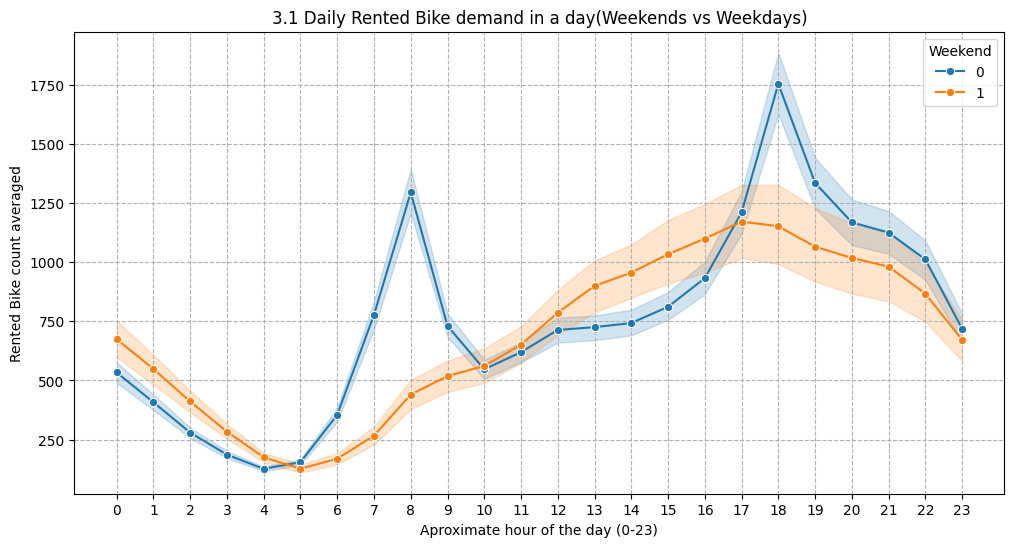

In [70]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=eda, x='Hour', y='Rented Bike Count', hue='Weekend', marker='o')
# 0 - 23 hours
plt.xticks(range(0, 24))
plt.title('3.1 Daily Rented Bike demand in a day(Weekends vs Weekdays)')
plt.xlabel('Aproximate hour of the day (0-23)')
plt.ylabel('Rented Bike count averaged')
plt.grid(True, linestyle='--')
#To save the lineplot
#plt.savefig('fig4_demand_weekend.png', dpi=150, bbox_inches='tight')

plt.show()

*Non vital cell*

Singular demand graph for seasons and Rainfall. This cell only prupose was to learn how to produce lineplot with hues, its kept to so you can produce a singular lineplot graph if needed.


```
# Seasons demand
plt.figure(figsize=(12, 6))
sns.lineplot(data=eda, x='Hour', y='Rented Bike Count', hue='Seasons', marker='o')
plt.xticks(range(0, 24))
plt.title('Average bike demand in a day compared by seasons')
plt.xlabel('Aproximate hour of the day (0-23)')
plt.ylabel('Rented Bike count averaged')
plt.grid(True, linestyle='--')
plt.show()
```


```
# Raining demand
eda['IsRaining'] = (eda['Rainfall(mm)'] > 0).astype(int)
plt.figure(figsize=(12, 6))
sns.lineplot(data=eda, x='Hour', y='Rented Bike Count', hue='IsRaining', marker='o')
plt.xticks(range(24))
plt.title('Daily Demand Regarding: Rain (1) vs Not Raining (0)')
plt.xlabel('Hour of the day (0-23)')
plt.ylabel('Average of rented Bikes')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
```




Using the same graph sketch we produce the complementary daily demand comparing each feature in hue.

To produce the lineplot by hue we will stablisht that:
* Rainfall and Solar Radiation can be turned into binary (0 for any 0 recording, 1 for any other to indicate presence).
* Temperature, Humidity, Wind speed and Visibility can divided into three levels and declaring the bins are necessary to understand the dimentions of the pd.cut accoreding to their respectrive meassuremnts and values
* Categorical variables are not needed to format.

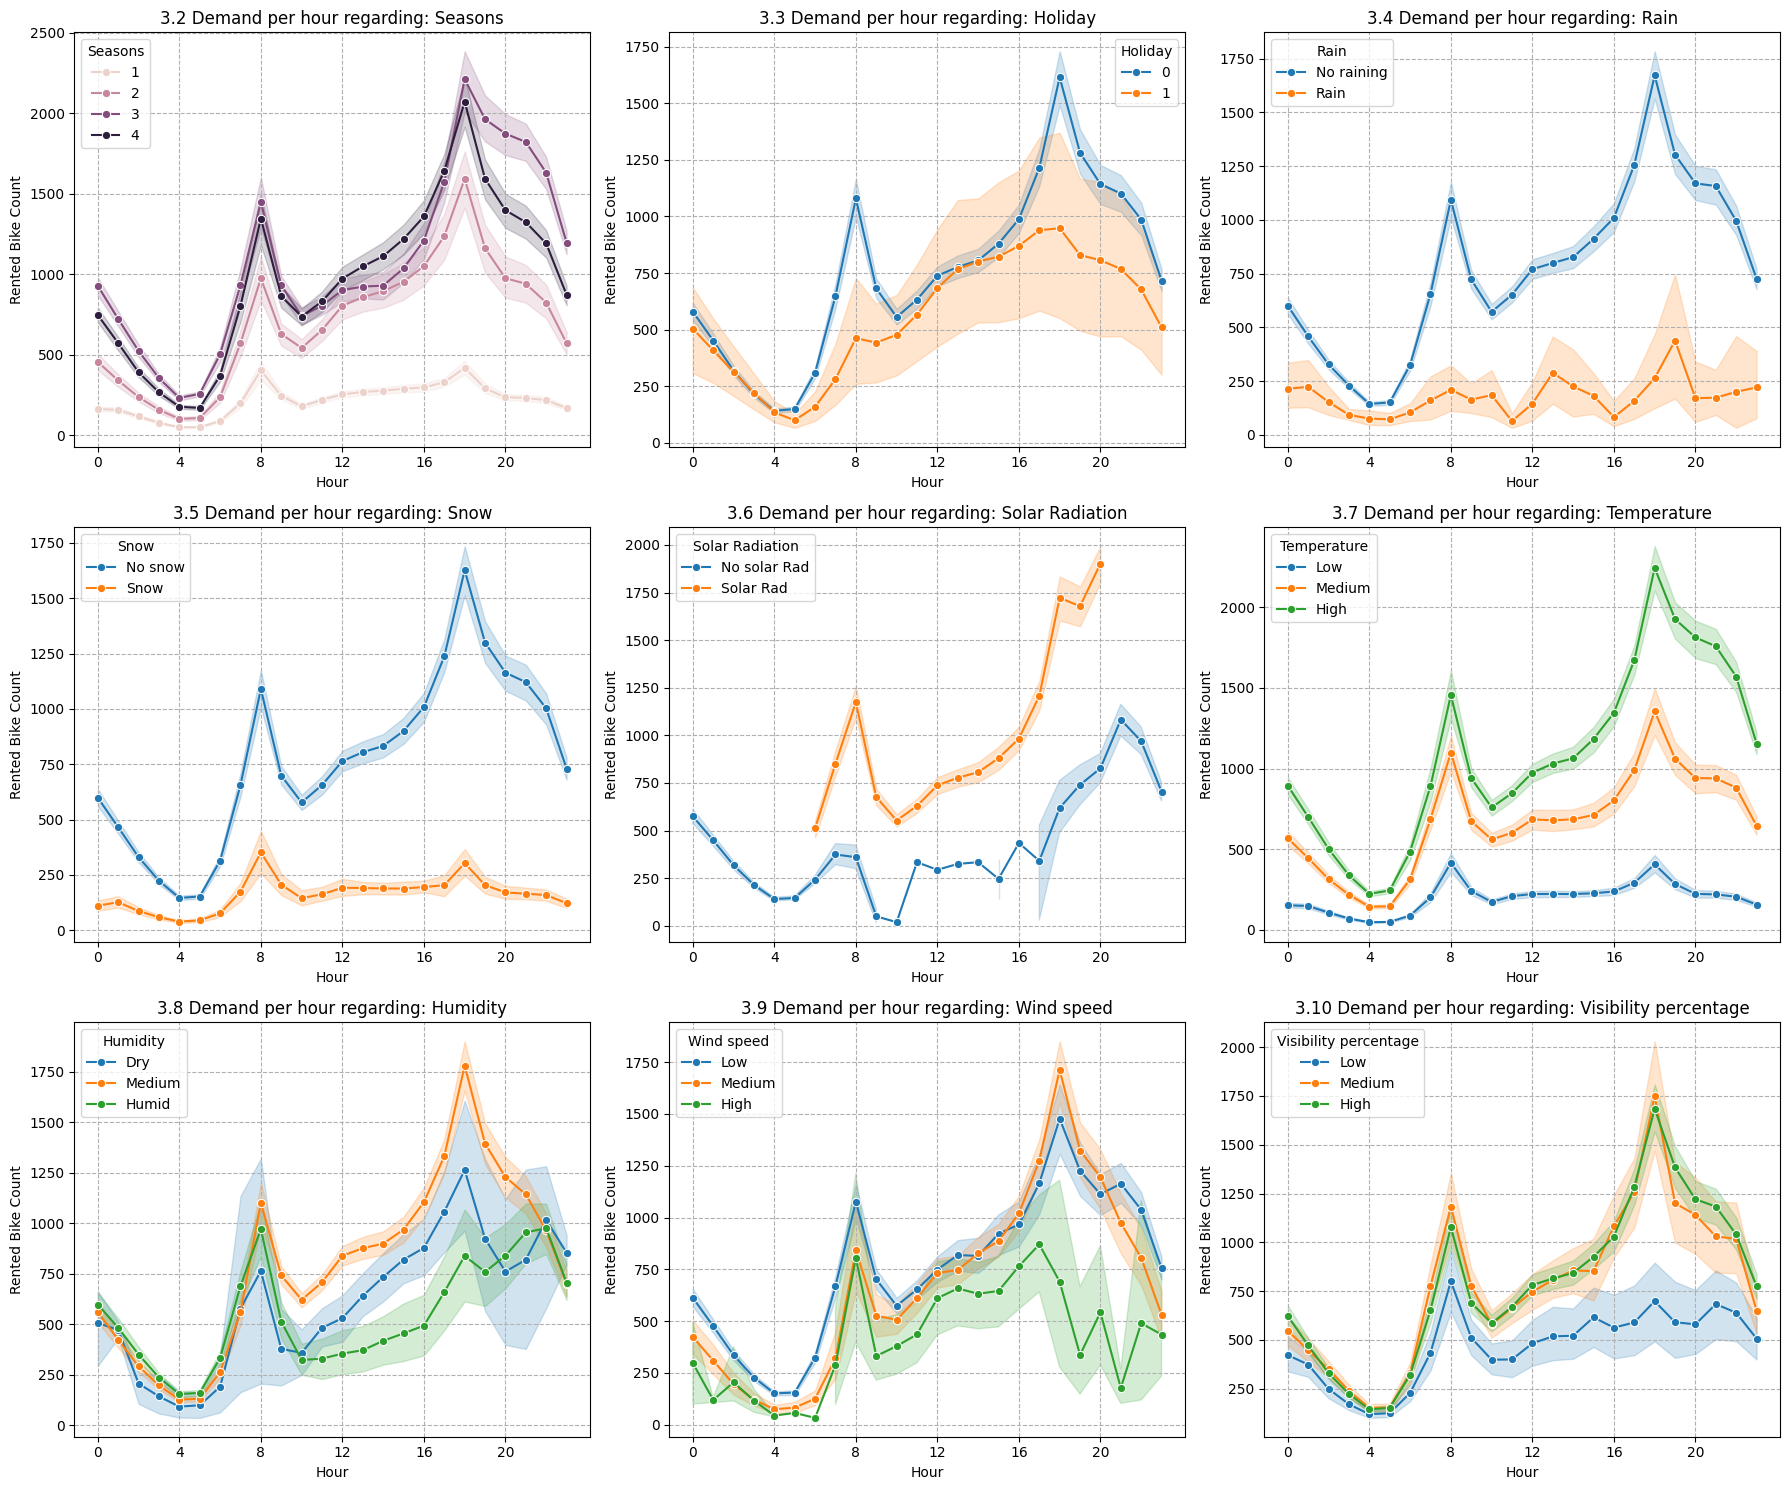

In [71]:
# Binary for this features
eda['Rain'] = (eda['Rainfall(mm)'] > 0).map({True: 'Rain', False: 'No raining'})
eda['Solar Radiation'] = (eda['Solar Radiation (MJ/m2)'] > 0).map({True: 'Solar Rad', False: 'No solar Rad'})
eda['Snow'] = (eda['Snowfall (cm)'] > 0).map({True: 'Snow', False: 'No snow'})
# Temperature reported was from -19 to 39 C
eda['Temperature'] = pd.cut(eda['Temperature(°C)'], bins=[-20, 0, 20, 40], labels=['Low', 'Medium', 'High'])
# Humidity goes 0 - 100%
eda['Humidity'] = pd.cut(eda['Humidity(%)'], bins=[0, 30, 70, 100], labels=['Dry', 'Medium', 'Humid'], include_lowest=True)
# Wind goes from 0 to a maximuim reported 7.4
eda['Wind speed'] = pd.cut(eda['Wind speed (m/s)'], bins=[0, 2, 4, 8], labels=['Low', 'Medium', 'High'], include_lowest=True)
#We include the line , include_lowest=True) due suspucion of exluding 0 values as nan
# Visibility goes from theroitical 0 up to 1
eda['Visibility percentage'] = pd.cut(eda['Visibility (10m)'], bins=[0, 0.33, 0.66, 1.0], labels=['Low', 'Medium', 'High'])
hue_variables = ['Seasons', 'Holiday', 'Rain', 'Snow', 'Solar Radiation', 'Temperature', 'Humidity', 'Wind speed', 'Visibility percentage']

n_rows = 3
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, hue_var in enumerate(hue_variables):
    sns.lineplot(data=eda, x='Hour', y='Rented Bike Count', hue=hue_var, marker='o', ax=axes[i])
    axes[i].set_xticks(range(0, 24, 4))
    axes[i].set_title(f'3.{i+2} Demand per hour regarding: {hue_var}')
    axes[i].grid(True, linestyle='--')

for j in range(len(hue_variables), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
#To save lineplots
#plt.savefig('fig5_demand_by_feature.png', dpi=150, bbox_inches='tight')
plt.show()

# Time series graphs
##Has the split of the subsets taken away important information?

The total demand of bikes in across all subsets can answer this question. Is important to this specific dataset because anomalies on the non trianed data could indicate a low accuracy on our final results.

To create time series we will for each subset we will extract each information from map. "map_df" Will be the copy we can manipulate to build the information re used across the eda.

In [72]:
map_df = pd.read_csv('map_seoulData.csv', encoding='latin1')
map_df['Date'] = pd.to_datetime(map_df['Date'])

map_train = map_df[map_df['Subset'] == 'train'].reset_index(drop=True)
map_val   = map_df[map_df['Subset'] == 'val'].reset_index(drop=True)
map_test  = map_df[map_df['Subset'] == 'test'].reset_index(drop=True)

We prepare the subset data to manipulate into graphs.

In [73]:
X_val = pd.read_csv('X_val_seoul.csv', encoding='utf-8')
Y_val = pd.read_csv('Y_val_seoul.csv', encoding='utf-8')
X_test = pd.read_csv('X_test_seoul.csv', encoding='utf-8')
Y_test = pd.read_csv('Y_test_seoul.csv', encoding='utf-8')

X_train_tag = X_train.copy(); X_train_tag['Subset'] = 'train'
X_val_tag   = X_val.copy();   X_val_tag['Subset']   = 'val'
X_test_tag  = X_test.copy();  X_test_tag['Subset']  = 'test'

X_train_tag['Rented Bike Count'] = Y_train.values
X_val_tag['Rented Bike Count']   = Y_val.values
X_test_tag['Rented Bike Count']  = Y_test.values

compare_df = pd.concat([X_train_tag, X_val_tag, X_test_tag], ignore_index=True)

We create a copy to manipulate date and apply "to_datetime".

In [74]:
eda_dated = eda.copy()
eda_dated['Date'] = pd.to_datetime(map_train['Date'])

**Non vital cell**

Information displayed of the begining and end of each subset only for visualization purposes.

In [75]:
print("\n--- Chronology of dates of subsets yyyy/mm/dd format ---")

changed = map_df['Subset'] != map_df['Subset'].shift()
change_idx = map_df.index[changed].tolist()

for i, start_idx in enumerate(change_idx):

    end_idx = change_idx[i+1] - 1 if i+1 < len(change_idx) else len(map_df) - 1
    subset_name = map_df.loc[start_idx, 'Subset']
    start_date = map_df.loc[start_idx, 'Date']
    end_date = map_df.loc[end_idx, 'Date']

    print(f"Chunk {i+1}: {subset_name} | Begins in: {start_date} | Ends: {end_date}")


--- Chronology of dates of subsets yyyy/mm/dd format ---
Chunk 1: train | Begins in: 2017-12-01 00:00:00 | Ends: 2018-02-19 00:00:00
Chunk 2: val | Begins in: 2018-02-20 00:00:00 | Ends: 2018-02-23 00:00:00
Chunk 3: test | Begins in: 2018-02-24 00:00:00 | Ends: 2018-02-28 00:00:00
Chunk 4: train | Begins in: 2018-03-01 00:00:00 | Ends: 2018-05-22 00:00:00
Chunk 5: val | Begins in: 2018-05-23 00:00:00 | Ends: 2018-05-26 00:00:00
Chunk 6: test | Begins in: 2018-05-27 00:00:00 | Ends: 2018-05-31 00:00:00
Chunk 7: train | Begins in: 2018-06-01 00:00:00 | Ends: 2018-08-22 00:00:00
Chunk 8: val | Begins in: 2018-08-23 00:00:00 | Ends: 2018-08-26 00:00:00
Chunk 9: test | Begins in: 2018-08-27 00:00:00 | Ends: 2018-08-31 00:00:00
Chunk 10: train | Begins in: 2018-09-01 00:00:00 | Ends: 2018-11-21 00:00:00
Chunk 11: val | Begins in: 2018-11-22 00:00:00 | Ends: 2018-11-25 00:00:00
Chunk 12: test | Begins in: 2018-11-26 00:00:00 | Ends: 2018-11-30 00:00:00


Evolution of daily total Rented Bikes across the whole data year (Train subset). Starting 2017-12-01 and ending 2018-11-30.

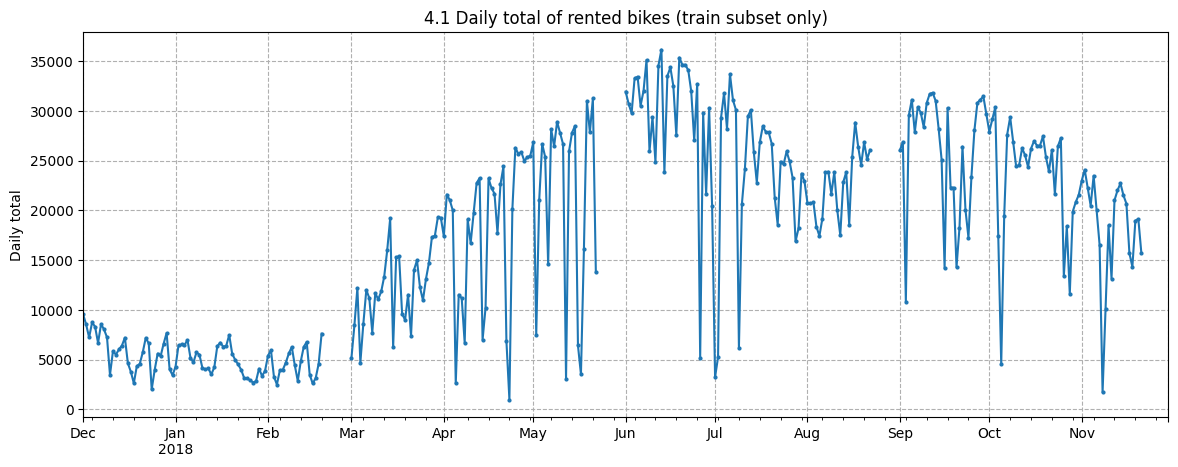

In [76]:
full_range = pd.date_range(map_df['Date'].min(), map_df['Date'].max(), freq='D')

daily_trainsum = (eda_dated.set_index('Date')['Rented Bike Count']
                  .resample('D').sum(min_count=1).reindex(full_range))

plt.figure(figsize=(14,5))
daily_trainsum.plot(marker='o', markersize=2)
plt.title('4.1 Daily total of rented bikes (train subset only)')
plt.ylabel('Daily total')
plt.grid(True, linestyle='--')
# To save graph
#plt.savefig('fig6_daily_train.png', dpi=150, bbox_inches='tight')
plt.show()

We start our investigation comparing the daily train sum to the daily sum of each subset.

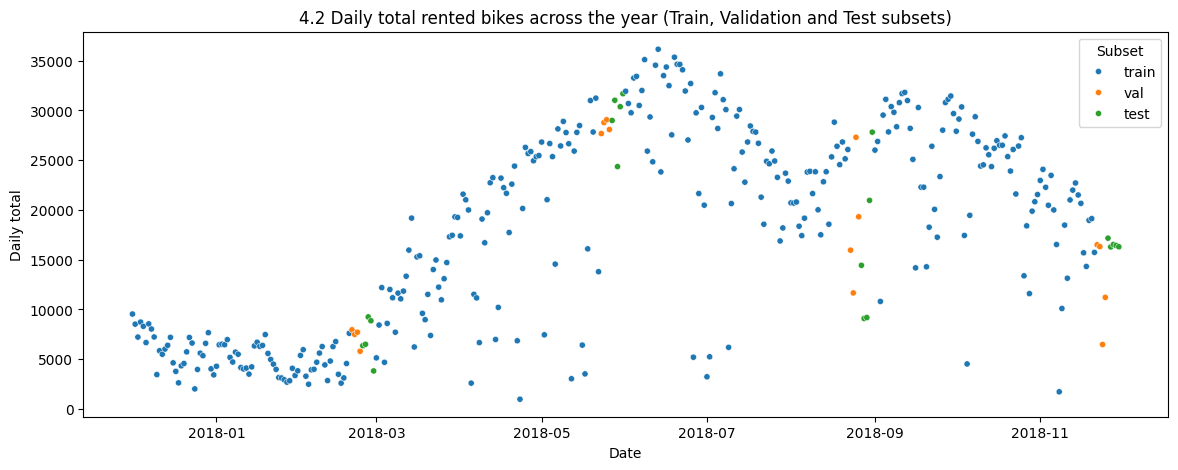

In [77]:
compare_dated = compare_df.copy()
compare_dated['Date'] = pd.concat(
    [map_train['Date'], map_val['Date'], map_test['Date']], ignore_index=True
)

daily_rb_subset = compare_dated.groupby(['Date', 'Subset'])['Rented Bike Count'].sum().reset_index()

#Scatterplot format as lineplot format re aranged my subsets along the graph
plt.figure(figsize=(14, 5))
sns.scatterplot(data=daily_rb_subset, x='Date', y='Rented Bike Count', hue='Subset', s=20)
plt.title('4.2 Daily total rented bikes across the year (Train, Validation and Test subsets)')
plt.ylabel('Daily total')
# To save
# plt.savefig('fig7_daily_all_subsets.png', dpi=150, bbox_inches='tight')
plt.show()

# Data description tables
### *The elephant in the room*. Outliers in the split problem.

Following the same question we want to know it the division of subset has taken away information on the X features that the model could benefit and if its not trained with this information this will be early indicators of a not accurate model.

We will double check the data description of the subsets to try and catch any outlier that could indicate the split will produce a bad lecture and prediction.

### *Non vital cell*
### DATA DESCRIBE FINDER FOR OUTLIER VISUALIZER

The next part of the code was a well evoluted code in which the idea was at first to aplly a .describe to each part of the subset to the features so it could tell me if there were extreme values that the model wouldnt pick therefore be the posible reason if the model had a low accuracy.

The mandatory variable to inspect was the rented bike count as having a higher mean, std or extreme outliers in the test and validate subset could be indication for the split and cause low acuracy  symptom. Then the idea evolved into checking this information by season as it could be the case of just one specific season and not all the data. Then this idea crashed into the fact that only checking the rented bike count would be incipient and it could need a higher inspection. Therefore we would need to inspect each feature. The creation of many tables caused migraine reading leading to this solution.

First we can discard categorical entries Hour	Seasons	Holiday	Weekend the description wont tell us any of these syptoms.
These leave us Temperature(°C)	Humidity(%)	Wind speed (m/s)	Visibility (10m)	Dew point temperature(°C)	Solar Radiation (MJ/m2)	Rainfall(mm)	Snowfall (cm)
These weather featuers will be subject to study the mean, min , max. Any outlier warning then will be subject to a critical inspection by season.

In [78]:
def outlierdata_visualizer(df, cols, group_cols, stats=['mean', 'std', 'min', 'max']):
    return df.groupby(group_cols)[cols].agg(stats).round(2)

weather_check_cols = ['Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)',
                       'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']

outlierdata_visualizer(compare_df, weather_check_cols, group_cols=['Subset']).T

Subset                           test  train    val
Temperature(°C)           mean  13.42  12.88  12.26
                          std    9.91  12.10  11.03
                          min   -3.10 -17.80  -4.30
                          max   30.30  39.40  32.00
Humidity(%)               mean  60.12  58.17  57.07
                          std   23.74  20.00  22.95
                          min    0.00   0.00  14.00
                          max   98.00  98.00  97.00
Wind speed (m/s)          mean   1.60   1.72   1.96
                          std    0.91   1.04   1.04
                          min    0.00   0.00   0.00
                          max    4.30   7.40   5.30
Visibility (10m)          mean   0.61   0.72   0.74
                          std    0.29   0.30   0.32
                          min    0.04   0.01   0.02
                          max    1.00   1.00   1.00
Dew point temperature(°C) mean   4.98   4.08   2.82
                          std   12.79  13.08  12.92
                          min  -19.00 -30.60 -22.00
                          max   24.50  27.20  23.60
Solar Radiation (MJ/m2)   mean   0.50   0.57   0.61
                          std    0.82   0.87   0.91
                          min    0.00   0.00   0.00
                          max    3.34   3.52   3.52
Rainfall(mm)              mean   0.40   0.14   0.10
                          std    2.23   1.04   0.60
                          min    0.00   0.00   0.00
                          max   29.50  35.00   9.10
Snowfall (cm)             mean   0.01   0.06   0.43
                          std    0.04   0.35   1.28
                          min    0.00   0.00   0.00
                          max    0.30   5.10   8.80

Code to paste the table into latex document.

In [79]:
# Table IV - Descriptive statistics per subset
#table4 = outlierdata_visualizer(compare_df, weather_check_cols, group_cols=['Subset']).T
#with open('table4_descriptive.tex', 'w') as f:
#    f.write(table4.to_latex(escape=True, float_format="%.2f"))

We found to be Temperature(°C), Rainfall(mm), Snowfall (cm), Wind speed (m/s) the most dangerous data split since train and validate contains key information of the feature.

In [80]:
critical_outlier = ['Temperature(°C)', 'Rainfall(mm)', 'Snowfall (cm)', 'Wind speed (m/s)']

outlierdata_visualizer(compare_df, critical_outlier, group_cols=['Seasons', 'Subset'])

Temperature(°C)                   Rainfall(mm)             \
                          mean   std   min   max         mean   std  min   
Seasons Subset                                                             
1       test              3.25  3.17  -3.1  10.3         0.19  1.25  0.0   
        train            -3.09  5.38 -17.8   8.7         0.02  0.31  0.0   
        val               1.28  3.44  -4.3   8.3         0.04  0.38  0.0   
2       test             21.03  3.44  14.3  28.7         0.01  0.09  0.0   
        train            12.27  6.37  -6.6  29.1         0.20  1.26  0.0   
        val              19.16  4.58  11.3  29.4         0.10  0.56  0.0   
3       test             24.45  2.05  20.3  30.3         1.40  4.13  0.0   
        train            26.75  4.80  16.3  39.4         0.19  1.30  0.0   
        val              25.69  2.99  20.4  32.0         0.13  0.34  0.0   
4       test              4.95  3.42  -1.5  13.2         0.00  0.00  0.0   
        train            15.23  6.46   0.3  30.5         0.13  0.98  0.0   
        val               2.90  2.83  -3.0   9.5         0.11  0.94  0.0   

                     Snowfall (cm)                 Wind speed (m/s)        \
                 max          mean   std  min  max             mean   std   
Seasons Subset                                                              
1       test     9.5          0.00  0.00  0.0  0.0             1.70  0.87   
        train    9.5          0.25  0.68  0.0  5.1             1.92  1.17   
        val      3.7          0.47  1.23  0.0  4.1             2.19  1.20   
2       test     1.0          0.00  0.00  0.0  0.0             1.81  0.89   
        train   35.0          0.00  0.00  0.0  0.0             1.87  1.08   
        val      3.5          0.00  0.00  0.0  0.0             2.03  1.15   
3       test    29.5          0.00  0.00  0.0  0.0             1.54  1.08   
        train   24.0          0.00  0.00  0.0  0.0             1.60  0.90   
        val      1.5          0.00  0.00  0.0  0.0             1.99  0.87   
4       test     0.0          0.02  0.08  0.0  0.3             1.34  0.71   
        train   18.0          0.00  0.00  0.0  0.0             1.50  0.94   
        val      9.1          1.25  2.01  0.0  8.8             1.63  0.81   

                          
                min  max  
Seasons Subset            
1       test    0.1  3.8  
        train   0.0  6.7  
        val     0.0  5.0  
2       test    0.3  4.2  
        train   0.1  7.4  
        val     0.4  5.3  
3       test    0.0  4.3  
        train   0.0  6.9  
        val     0.1  4.5  
4       test    0.2  3.3  
        train   0.0  5.7  
        val     0.4  3.4

Latex print.

In [81]:
# Table V - Critical variables per season and subset (longtable)
#blocks = {}
#for var in critical_outlier:
#    blocks[var] = outlierdata_visualizer(compare_df, [var], group_cols=['Seasons', 'Subset'])[var]
#
#table5 = pd.concat(blocks, names=['Variable'])
#with open('table5_critical.tex', 'w') as f:
#    f.write(table5.to_latex(escape=True, float_format="%.2f", longtable=True,
#                            caption="Critical statistical values for all subsets",
#                            label="tab:critical_outlier"))

We want to scope even further into Rainfall(mm) and Snowfall (cm). We have found a big warning. During Autumn the test and validation are presented with snowfall presence while train is not met with this data. With rainfall

In [82]:
def event_frequency(series):
    return round((series > 0).mean() * 100, 1)

compare_df.groupby(['Seasons', 'Subset'])[['Rainfall(mm)', 'Snowfall (cm)']].agg(['max', event_frequency])

Rainfall(mm)                 Snowfall (cm)                
                        max event_frequency           max event_frequency
Seasons Subset                                                           
1       test            9.5             2.5           0.0             0.0
        train           9.5             1.9           5.1            19.4
        val             3.7             2.1           4.1            14.6
2       test            1.0             0.8           0.0             0.0
        train          35.0             9.3           0.0             0.0
        val             3.5             4.2           0.0             0.0
3       test           29.5            34.2           0.0             0.0
        train          24.0             6.8           0.0             0.0
        val             1.5            21.9           0.0             0.0
4       test            0.0             0.0           0.3             8.3
        train          18.0             4.9           0.0             0.0
        val             9.1             2.1           8.8            42.7

Latex print

In [83]:
# Table VI - Rainfall and snowfall extremes and frequency
#table6 = compare_df.groupby(['Seasons', 'Subset'])[['Rainfall(mm)', 'Snowfall (cm)']].agg(['max', event_frequency])
#table6 = table6.rename(columns={'event_frequency': '% of hours'}, level=1)
#with open('table6_rain_snow.tex', 'w') as f:
#    f.write(table6.to_latex(escape=True, float_format="%.2f"))

In [84]:
outlierdata_visualizer(compare_df, ['Rented Bike Count'], group_cols=['Seasons', 'Subset'])

Rented Bike Count                   
                            mean     std  min   max
Seasons Subset                                     
1       test              289.88  209.44    7   929
        train             217.81  142.35    3   937
        val               301.61  179.44   32   784
2       test             1220.16  740.28  134  3251
        train             702.50  587.18    2  3130
        val              1183.24  703.37   25  3123
3       test              679.06  646.26   10  2836
        train            1068.03  691.68    9  3556
        val               773.21  516.11   30  2080
4       test              689.07  373.12   95  1708
        train             961.09  627.05    2  3298
        val               526.03  348.47   24  1671

In [85]:
# Table VII - Rented Bike Count per season and subset
#table7 = outlierdata_visualizer(compare_df, ['Rented Bike Count'], group_cols=['Seasons', 'Subset'])
#with open('table7_rented_bikes.tex', 'w') as f:
#    f.write(table7.to_latex(escape=True, float_format="%.2f"))

# ZOOM OUT

At last we can produce our visual support on our critical outliers. We can produce the boxplot for each subset for each season.

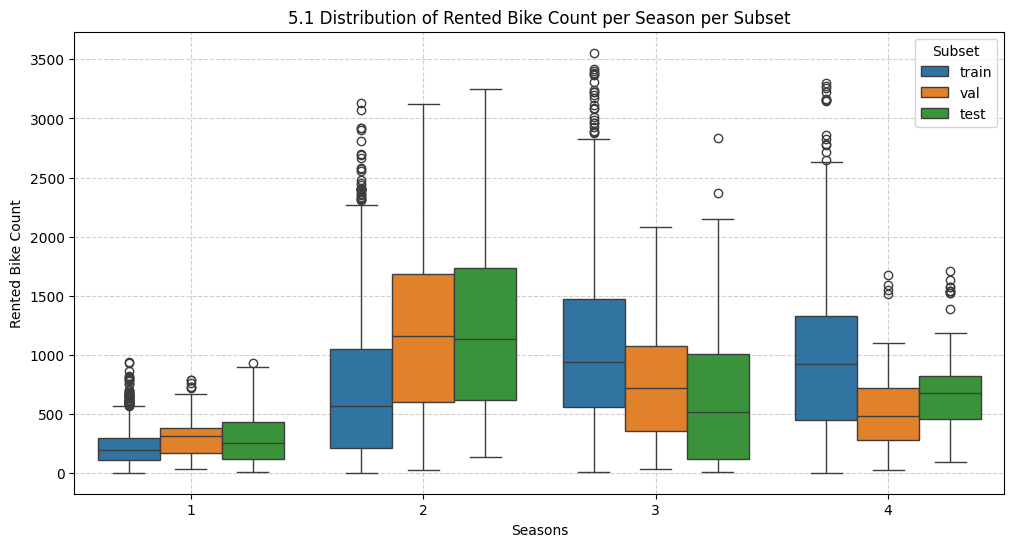

In [86]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=compare_df, x='Seasons', y='Rented Bike Count', hue='Subset')
plt.title('5.1 Distribution of Rented Bike Count per Season per Subset')
plt.grid(True, linestyle='--', alpha=0.6)
# to save
# plt.savefig('fig8_zoomout_season.png', dpi=150, bbox_inches='tight')
plt.show()

The purposes of these graphs is to double check if train susbset contains the most representative outliers.

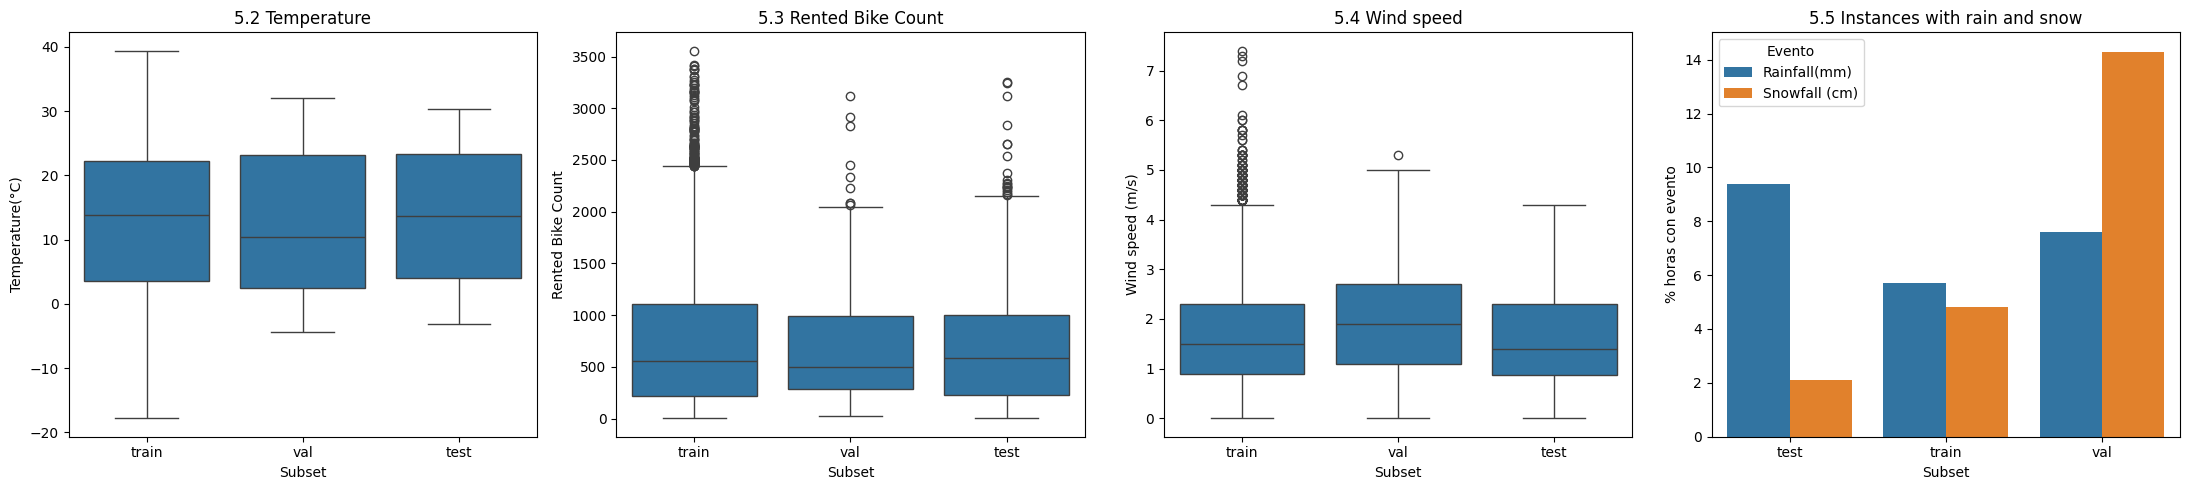

In [87]:
fig, axes = plt.subplots(1, 4, figsize=(22,5))
sns.boxplot(data=compare_df, x='Subset', y='Temperature(°C)', ax=axes[0])
sns.boxplot(data=compare_df, x='Subset', y='Rented Bike Count', ax=axes[1])
sns.boxplot(data=compare_df, x='Subset', y='Wind speed (m/s)', ax=axes[2])

event_pct = compare_df.groupby('Subset')[['Rainfall(mm)', 'Snowfall (cm)']].agg(event_frequency).reset_index()
event_pct_melt = event_pct.melt(id_vars='Subset', var_name='Evento', value_name='% horas con evento')
sns.barplot(data=event_pct_melt, x='Subset', y='% horas con evento', hue='Evento', ax=axes[3])

for i, (ax, title) in enumerate(zip(axes, ['5.2 Temperature', '5.3 Rented Bike Count', '5.4 Wind speed', '5.5 Instances with rain and snow'])): # Updated titles
    ax.set_title(title)
plt.tight_layout()
# to save
#plt.savefig('fig9_zoomout_features.png', dpi=150, bbox_inches='tight')
plt.show()

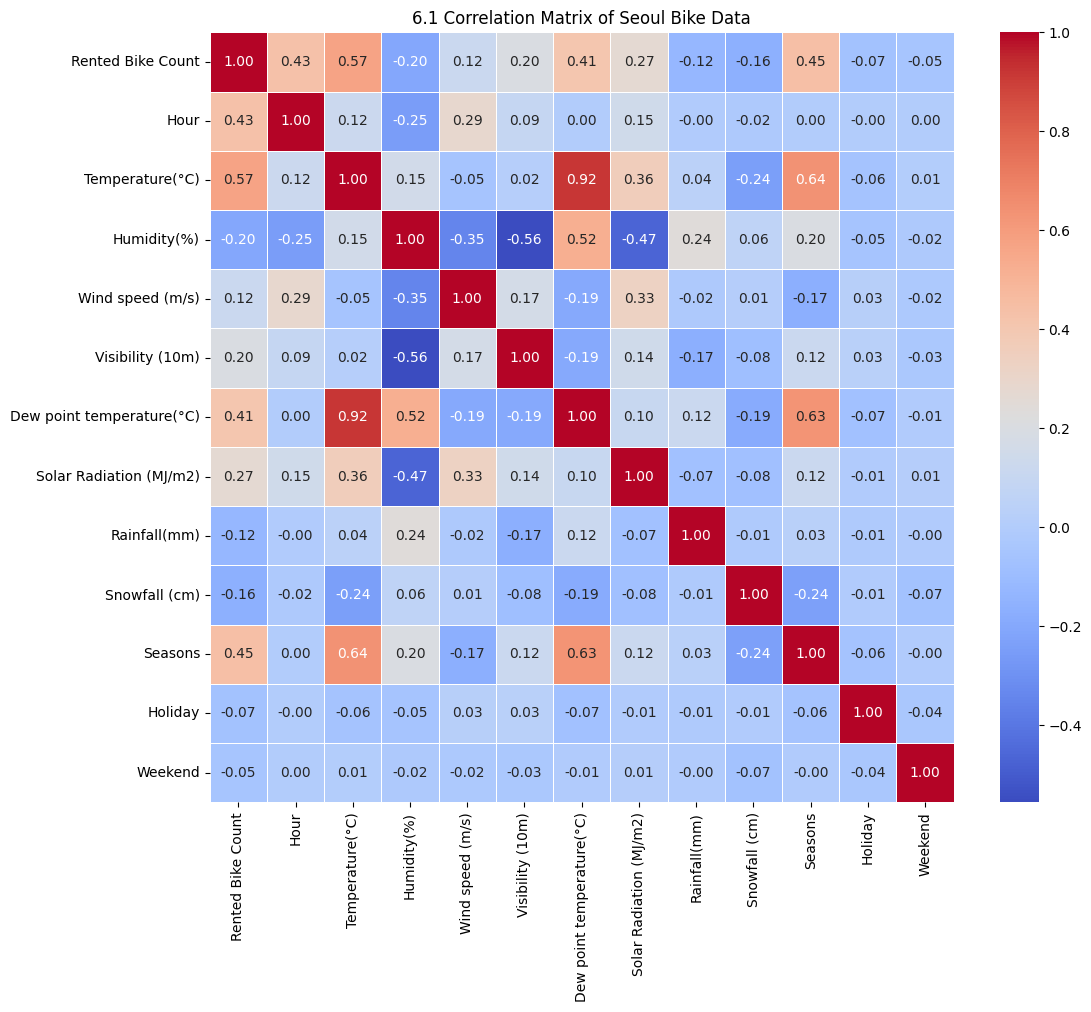

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Weekend
Rented Bike Count,1.000000,4.314949e-01,0.568806,-0.204609,0.116784,0.202985,0.410603,0.270574,-0.124127,-0.160600,4.469185e-01,-6.622977e-02,-5.078054e-02
Hour,0.431495,1.000000e+00,0.123944,-0.250625,0.286046,0.094276,0.002689,0.146087,-0.004788,-0.017776,2.421916e-15,-7.305323e-17,2.091163e-17
Temperature(°C),0.568806,1.239441e-01,1.000000,0.150700,-0.054583,0.017153,0.916449,0.358708,0.044078,-0.242231,6.382008e-01,-5.827891e-02,8.263617e-03
Humidity(%),-0.204609,-2.506251e-01,0.150700,1.000000,-0.348048,-0.555083,0.523785,-0.468178,0.237071,0.063842,2.001643e-01,-5.336654e-02,-1.858839e-02
Wind speed (m/s),0.116784,2.860463e-01,-0.054583,-0.348048,1.000000,0.166643,-0.192891,0.326780,-0.018329,0.012694,-1.664827e-01,2.508994e-02,-2.340794e-02
Visibility (10m),0.202985,9.427611e-02,0.017153,-0.555083,0.166643,1.000000,-0.190935,0.143782,-0.169316,-0.083347,1.161542e-01,2.926906e-02,-3.085024e-02
Dew point temperature(°C),0.410603,2.689248e-03,0.916449,0.523785,-0.192891,-0.190935,1.000000,0.103978,0.118979,-0.188501,6.320733e-01,-7.052043e-02,-7.454571e-03
Solar Radiation (MJ/m2),0.270574,1.460871e-01,0.358708,-0.468178,0.326780,0.143782,0.103978,1.000000,-0.072538,-0.078358,1.184770e-01,-6.016619e-03,1.092296e-02
Rainfall(mm),-0.124127,-4.788376e-03,0.044078,0.237071,-0.018329,-0.169316,0.118979,-0.072538,1.000000,-0.008456,3.362427e-02,-1.335669e-02,-4.835409e-03
Snowfall (cm),-0.160600,-1.777570e-02,-0.242231,0.063842,0.012694,-0.083347,-0.188501,-0.078358,-0.008456,1.000000,-2.365796e-01,-7.551231e-03,-6.870132e-02


In [88]:
original_cols = ['Rented Bike Count','Hour','Temperature(°C)','Humidity(%)','Wind speed (m/s)',
                   'Visibility (10m)','Dew point temperature(°C)','Solar Radiation (MJ/m2)',
                   'Rainfall(mm)','Snowfall (cm)','Seasons','Holiday','Weekend']
r = eda[original_cols].corr()


plt.figure(figsize=(12, 10))
sns.heatmap(r, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('6.1 Correlation Matrix of Seoul Bike Data')
# to save
#	plt.savefig('fig10_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

display(r)

Latex print. This table was not included in the document.

In [89]:
# Correlation matrix
#with open('table8_correlation.tex', 'w') as f:
#    f.write(r.to_latex(escape=True, float_format="%.2f"))

We are now ready to start our models.